<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/15_EnsembleLearningBoostingTechnique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
data = fetch_california_housing()
X= data.data
y = data.target
df = pd.DataFrame(X, columns=data.feature_names)
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [ ]:
y = data.target
X_train, X_test, y_train, y_test = train_test_split( X,y, test_size=0.2, random_state=42)

In [ ]:
results = {}

#ADABoost Regressor

In [ ]:
start = time.time()
ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

pred = ada.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
runtime = time.time() - start
results["AdaBoost"] = [rmse, runtime]

#Gradient BoostRegressor

In [ ]:
start = time.time()
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
pred = gbr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
runtime = time.time() - start
results["GradientBoostingRegressor"] = [rmse, runtime]

#XGBoost Regressor

In [ ]:
start = time.time()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
runtime = time.time() - start
results["XGBoost"] = [rmse, runtime]


#LightGBM Regressor

In [ ]:
start = time.time()
lgb = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
lgb.fit(X_train, y_train)
pred = lgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
runtime = time.time() - start
results["LightGBM"] = [rmse, runtime]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002713 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#Display Results

In [ ]:
df = pd.DataFrame(results, index=["RMSE", "Runtime"])
print(df)

         AdaBoost  GradientBoostingRegressor   XGBoost  LightGBM
RMSE     0.783887                   0.542215  0.543348  0.537958
Runtime  0.778847                   6.242086  0.213549  0.284484


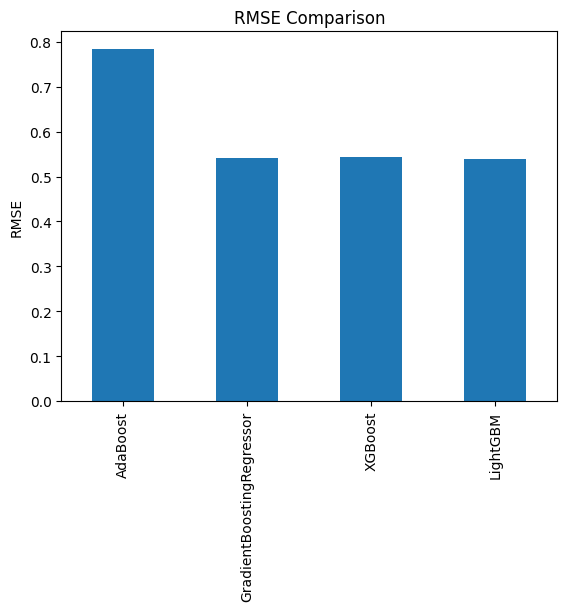

In [ ]:
#visualization
df.loc["RMSE"].plot(kind="bar", title="RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

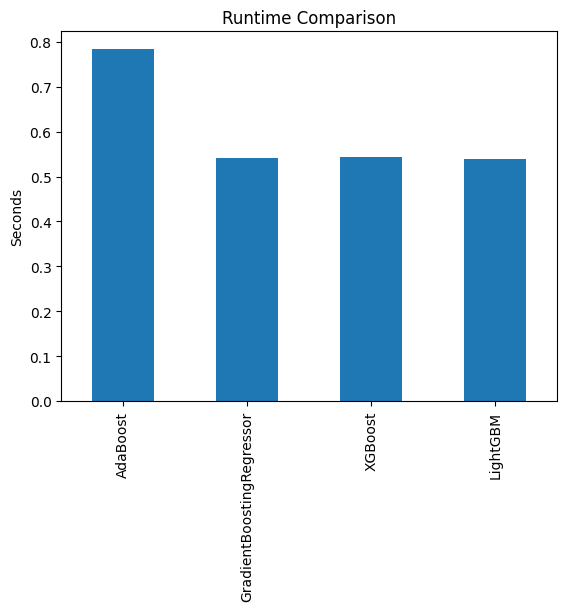

In [ ]:
df.loc["RMSE"].plot(kind="bar", title="Runtime Comparison")
plt.ylabel("Seconds")
plt.show()